# C-MAPSS FD001 Failure Risk and Alert Baseline

This notebook completes the telemetry baseline after RUL regression.

Outputs:

- predicted RUL;
- probability of failure within 30 cycles;
- `normal`, `warning`, or `critical` severity;
- alert evaluation, including critical-fault recall and false alarms;
- a JSON telemetry contract for the future RCA agent.

The classifier is trained with engine-level separation to prevent leakage.


## 1. Configuration

Do not rerun package upgrades if the environment already contains the required
libraries. The earlier server run upgraded NumPy beyond some OpenCV/Numba
constraints.


In [1]:
# Run only when packages are missing:
%pip install "numpy<2.3" "pandas<3" scikit-learn xgboost matplotlib seaborn



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from xgboost import XGBClassifier, XGBRegressor

SEED = 42
RUL_CAP = 125
CRITICAL_RUL = 15
FAILURE_HORIZON = 30
WARNING_RUL = 60
ROLLING_WINDOWS = (5, 10, 20)

random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

ARTIFACT_DIR = Path("artifacts/cmapss/fd001")
RISK_DIR = ARTIFACT_DIR / "risk"
FIGURE_DIR = RISK_DIR / "figures"
RISK_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd().resolve())
print("Risk artifacts:", RISK_DIR.resolve())


Working directory: /workspace/notebooks
Risk artifacts: /workspace/notebooks/artifacts/cmapss/fd001/risk


## 2. Load FD001 and Recreate the Feature Contract


In [3]:
COLUMNS = (
    ["unit", "cycle"]
    + [f"op_setting_{index}" for index in range(1, 4)]
    + [f"sensor_{index}" for index in range(1, 22)]
)

DATA_CANDIDATES = (
    Path("data/CMAPSSData"),
    Path("data"),
    Path("../data/CMAPSSData"),
    Path("../data"),
    Path("CMAPSSData"),
)


def resolve_data_dir() -> Path:
    required = ("train_FD001.txt", "test_FD001.txt", "RUL_FD001.txt")
    for candidate in DATA_CANDIDATES:
        if all((candidate / name).is_file() for name in required):
            return candidate
    raise FileNotFoundError("Could not locate the three FD001 data files.")


DATA_DIR = resolve_data_dir()
train_raw = pd.read_csv(
    DATA_DIR / "train_FD001.txt", sep=r"\s+", header=None, names=COLUMNS
)
test_raw = pd.read_csv(
    DATA_DIR / "test_FD001.txt", sep=r"\s+", header=None, names=COLUMNS
)
test_rul = pd.read_csv(
    DATA_DIR / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
)

max_cycle = train_raw.groupby("unit")["cycle"].transform("max")
train_raw["RUL_raw"] = max_cycle - train_raw["cycle"]
train_raw["RUL"] = train_raw["RUL_raw"].clip(upper=RUL_CAP)
train_raw["failure_within_horizon"] = (
    train_raw["RUL_raw"] <= FAILURE_HORIZON
).astype(int)

candidate_features = [
    column for column in COLUMNS if column != "unit"
]
feature_std = train_raw[candidate_features].std()
constant_columns = feature_std[feature_std <= 1e-8].index.tolist()
base_features = [
    column for column in candidate_features if column not in constant_columns
]
sensor_features = [
    column for column in base_features if column.startswith("sensor_")
]

print("Data directory:", DATA_DIR.resolve())
print("Constant columns:", constant_columns)
print("Positive training rate:", train_raw["failure_within_horizon"].mean())


Data directory: /workspace/notebooks/data/CMAPSSData
Constant columns: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Positive training rate: 0.15025931850128446


In [4]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.sort_values(["unit", "cycle"]).copy()
    grouped = result.groupby("unit", sort=False)
    derived = {}

    for sensor in sensor_features:
        derived[f"{sensor}_delta"] = grouped[sensor].diff().fillna(0.0)

    for window in ROLLING_WINDOWS:
        for sensor in sensor_features:
            rolling = grouped[sensor].rolling(window=window, min_periods=1)
            derived[f"{sensor}_mean_{window}"] = (
                rolling.mean().reset_index(level=0, drop=True)
            )
            derived[f"{sensor}_std_{window}"] = (
                rolling.std().reset_index(level=0, drop=True).fillna(0.0)
            )

    return pd.concat([result, pd.DataFrame(derived, index=result.index)], axis=1)


train_features = engineer_features(train_raw)
test_features = engineer_features(test_raw)

excluded = {"unit", "RUL", "RUL_raw", "failure_within_horizon"}
feature_columns = [
    column for column in train_features.columns if column not in excluded
]

assert not train_features[feature_columns].isna().any().any()
assert set(feature_columns).issubset(test_features.columns)
print("Feature count:", len(feature_columns))


Feature count: 130


## 3. Engine-Level Train/Validation Split

Class imbalance is handled with `scale_pos_weight`. The validation threshold is
selected by F1 score, then frozen for official test evaluation.


In [5]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=SEED,
)
train_index, validation_index = next(
    splitter.split(
        train_features,
        groups=train_features["unit"],
    )
)

development = train_features.iloc[train_index].copy()
validation = train_features.iloc[validation_index].copy()

X_train = development[feature_columns]
y_train = development["failure_within_horizon"]
X_validation = validation[feature_columns]
y_validation = validation["failure_within_horizon"]

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

assert set(development["unit"]).isdisjoint(set(validation["unit"]))
print("Training engines:", development["unit"].nunique())
print("Validation engines:", validation["unit"].nunique())
print("scale_pos_weight:", round(scale_pos_weight, 3))


Training engines: 80
Validation engines: 20
scale_pos_weight: 5.678


## 4. Train Imminent-Failure Classifier


In [6]:
classifier_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 400,
    "learning_rate": 0.05,
    "max_depth": 5,
    "min_child_weight": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "scale_pos_weight": scale_pos_weight,
    "random_state": SEED,
    "n_jobs": -1,
    "tree_method": "hist",
}

classifier = XGBClassifier(**classifier_params)
classifier.fit(X_train, y_train)

validation_probability = classifier.predict_proba(X_validation)[:, 1]
print("Validation ROC AUC:", roc_auc_score(y_validation, validation_probability))
print(
    "Validation PR AUC:",
    average_precision_score(y_validation, validation_probability),
)


Validation ROC AUC: 0.993643291257597
Validation PR AUC: 0.9712691120016278


## 5. Select Alert Threshold on Validation Engines


,threshold,roc_auc,pr_auc,precision,recall,f1
0,0.624599,0.993643,0.971269,0.891167,0.91129,0.901116


              precision    recall  f1-score   support

           0     0.9840    0.9800    0.9820      3450
           1     0.8912    0.9113    0.9011       620

    accuracy                         0.9695      4070
   macro avg     0.9376    0.9456    0.9416      4070
weighted avg     0.9699    0.9695    0.9697      4070



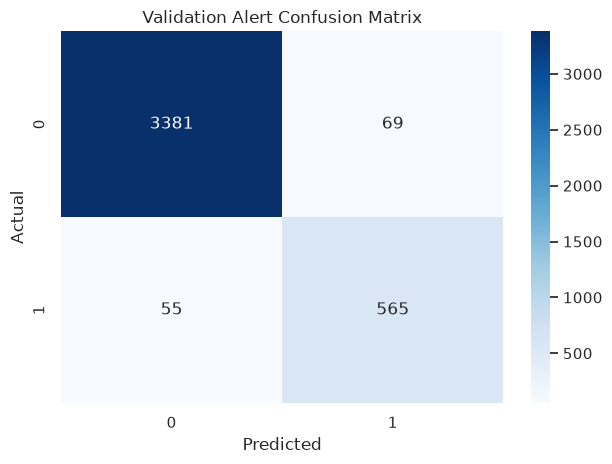

In [7]:
precision, recall, thresholds = precision_recall_curve(
    y_validation,
    validation_probability,
)

threshold_scores = pd.DataFrame(
    {
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    }
)
threshold_scores["f1"] = (
    2
    * threshold_scores["precision"]
    * threshold_scores["recall"]
    / (
        threshold_scores["precision"]
        + threshold_scores["recall"]
        + 1e-12
    )
)

best_threshold_row = threshold_scores.loc[threshold_scores["f1"].idxmax()]
ALERT_THRESHOLD = float(best_threshold_row["threshold"])
validation_alert = (validation_probability >= ALERT_THRESHOLD).astype(int)

validation_metrics = {
    "threshold": ALERT_THRESHOLD,
    "roc_auc": float(roc_auc_score(y_validation, validation_probability)),
    "pr_auc": float(average_precision_score(y_validation, validation_probability)),
    "precision": float(precision_score(y_validation, validation_alert)),
    "recall": float(recall_score(y_validation, validation_alert)),
    "f1": float(f1_score(y_validation, validation_alert)),
}

display(pd.DataFrame([validation_metrics]))
print(classification_report(y_validation, validation_alert, digits=4))

matrix = confusion_matrix(y_validation, validation_alert)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Alert Confusion Matrix")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "validation_confusion_matrix.png", dpi=150)
plt.show()


## 6. Retrain Classifier on All Training Engines

The selected threshold remains fixed. Only model parameters are retrained using
all available FD001 training engines.


In [8]:
full_labels = train_features["failure_within_horizon"]
full_negative = int((full_labels == 0).sum())
full_positive = int((full_labels == 1).sum())
final_classifier_params = {
    **classifier_params,
    "scale_pos_weight": full_negative / full_positive,
}

final_classifier = XGBClassifier(**final_classifier_params)
final_classifier.fit(train_features[feature_columns], full_labels)

print("Final classifier trained on", train_features["unit"].nunique(), "engines.")


Final classifier trained on 100 engines.


## 7. Load the Saved RUL Regressor

This notebook expects the artifact created by `rul_baseline.ipynb`. If it is
missing, run that notebook's artifact-saving cell first.


In [9]:
rul_model_path = ARTIFACT_DIR / "xgboost_fd001_rul.json"
metadata_path = ARTIFACT_DIR / "metadata.json"

if not rul_model_path.is_file() or not metadata_path.is_file():
    raise FileNotFoundError(
        "RUL artifacts are missing. Run rul_baseline.ipynb through its save cell."
    )

rul_metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
rul_feature_columns = rul_metadata["feature_columns"]

if rul_feature_columns != feature_columns:
    raise ValueError(
        "Risk notebook features differ from the saved RUL model contract."
    )

rul_model = XGBRegressor()
rul_model.load_model(rul_model_path)
print("Loaded RUL model:", rul_model_path.resolve())


Loaded RUL model: /workspace/notebooks/artifacts/cmapss/fd001/xgboost_fd001_rul.json


## 8. Official Test Endpoint Evaluation


In [10]:
test_last_rows = (
    test_features.sort_values(["unit", "cycle"])
    .groupby("unit", as_index=False)
    .tail(1)
    .sort_values("unit")
    .reset_index(drop=True)
)

true_test_rul = test_rul["RUL"].to_numpy()
true_test_failure = (true_test_rul <= FAILURE_HORIZON).astype(int)

predicted_rul = np.clip(
    rul_model.predict(test_last_rows[feature_columns]),
    0,
    RUL_CAP,
)
failure_probability = final_classifier.predict_proba(
    test_last_rows[feature_columns]
)[:, 1]
predicted_failure = (failure_probability >= ALERT_THRESHOLD).astype(int)

test_metrics = {
    "roc_auc": float(roc_auc_score(true_test_failure, failure_probability)),
    "pr_auc": float(
        average_precision_score(true_test_failure, failure_probability)
    ),
    "precision": float(precision_score(true_test_failure, predicted_failure)),
    "recall": float(recall_score(true_test_failure, predicted_failure)),
    "f1": float(f1_score(true_test_failure, predicted_failure)),
    "false_alarms": int(
        ((predicted_failure == 1) & (true_test_failure == 0)).sum()
    ),
    "missed_failures": int(
        ((predicted_failure == 0) & (true_test_failure == 1)).sum()
    ),
}

display(pd.DataFrame([test_metrics]))
print(classification_report(true_test_failure, predicted_failure, digits=4))
?

,roc_auc,pr_auc,precision,recall,f1,false_alarms,missed_failures
0,0.989867,0.967928,0.913043,0.84,0.875,2,4


              precision    recall  f1-score   support

           0     0.9481    0.9733    0.9605        75
           1     0.9130    0.8400    0.8750        25

    accuracy                         0.9400       100
   macro avg     0.9305    0.9067    0.9178       100
weighted avg     0.9393    0.9400    0.9391       100




IPython -- An enhanced Interactive Python

IPython offers a fully compatible replacement for the standard Python
interpreter, with convenient shell features, special commands, command
history mechanism and output results caching.

At your system command line, type 'ipython -h' to see the command line
options available. This document only describes interactive features.

GETTING HELP
------------

Within IPython you have various way to access help:

  ?         -> Introduction and overview of IPython's features (this screen).
  object?   -> Details about 'object'.
  object??  -> More detailed, verbose information about 'object'.
  %quickref -> Quick reference of all IPython specific syntax and magics.
  help      -> Access Python's own help system.

If you are in terminal IPython you can quit this screen by pressing `q`.


MAIN FEATURES
-------------

* Access to the standard Python help with object docstrings and the Python
  manuals. Simply type 'help' (no quotes) to invoke it.

* Ma

## 9. Build the Telemetry Output Contract


In [11]:
def severity_from_rul(rul: float) -> str:
    if rul <= CRITICAL_RUL:
        return "critical"
    if rul <= WARNING_RUL:
        return "warning"
    return "normal"


results = pd.DataFrame(
    {
        "scenario_id": [
            f"CMAPSS-FD001-{unit:03d}"
            for unit in test_last_rows["unit"].astype(int)
        ],
        "asset_id": [
            f"ENGINE-{unit:03d}"
            for unit in test_last_rows["unit"].astype(int)
        ],
        "unit": test_last_rows["unit"].astype(int),
        "last_cycle": test_last_rows["cycle"].astype(int),
        "predicted_rul": predicted_rul,
        "failure_probability_30_cycles": failure_probability,
        "alert": predicted_failure.astype(bool),
        "true_rul": true_test_rul,
    }
)
results["severity"] = results["predicted_rul"].map(severity_from_rul)

display(results.head(10))

sample = results.iloc[0]
telemetry_contract_example = {
    "scenario_id": sample["scenario_id"],
    "asset_id": sample["asset_id"],
    "anomaly_score": float(sample["failure_probability_30_cycles"]),
    "failure_risk": float(sample["failure_probability_30_cycles"]),
    "predicted_rul": float(sample["predicted_rul"]),
    "severity": sample["severity"],
    "alert": bool(sample["alert"]),
    "evidence": {
        "last_observed_cycle": int(sample["last_cycle"]),
        "failure_horizon_cycles": FAILURE_HORIZON,
        "alert_threshold": ALERT_THRESHOLD,
    },
    "limitations": [
        "FD001 represents simulated turbofan degradation.",
        "This telemetry result is a baseline for the industrial demo.",
    ],
}

print(json.dumps(telemetry_contract_example, indent=2))



,scenario_id,asset_id,unit,last_cycle,predicted_rul,failure_probability_30_cycles,alert,true_rul,severity
0,CMAPSS-FD001-001,ENGINE-001,1,31,125.000000,0.000009,False,112,normal
1,CMAPSS-FD001-002,ENGINE-002,2,49,123.407043,0.000013,False,98,normal
2,CMAPSS-FD001-003,ENGINE-003,3,126,47.275261,0.081139,False,69,warning
3,CMAPSS-FD001-004,ENGINE-004,4,106,88.829926,0.000961,False,82,normal
4,CMAPSS-FD001-005,ENGINE-005,5,98,89.830399,0.000527,False,91,normal
5,CMAPSS-FD001-006,ENGINE-006,6,105,98.253067,0.000111,False,93,normal
6,CMAPSS-FD001-007,ENGINE-007,7,160,107.553772,0.000039,False,91,normal
7,CMAPSS-FD001-008,ENGINE-008,8,166,78.725616,0.000326,False,95,normal
8,CMAPSS-FD001-009,ENGINE-009,9,55,120.155510,0.000078,False,111,normal
9,CMAPSS-FD001-010,ENGINE-010,10,192,104.031242,0.000049,False,96,normal


{
  "scenario_id": "CMAPSS-FD001-001",
  "asset_id": "ENGINE-001",
  "anomaly_score": 9.042365491040982e-06,
  "failure_risk": 9.042365491040982e-06,
  "predicted_rul": 125.0,
  "severity": "normal",
  "alert": false,
  "evidence": {
    "last_observed_cycle": 31,
    "failure_horizon_cycles": 30,
    "alert_threshold": 0.6245986223220825
  },
  "limitations": [
    "FD001 represents simulated turbofan degradation.",
    "This telemetry result is a baseline for the industrial demo."
  ]
}


## 10. Save Artifacts


In [12]:
classifier_path = RISK_DIR / "xgboost_fd001_failure_classifier.json"
metadata_output_path = RISK_DIR / "metadata.json"
results_path = RISK_DIR / "official_test_risk_outputs.csv"
example_path = RISK_DIR / "telemetry_contract_example.json"

final_classifier.save_model(classifier_path)
results.to_csv(results_path, index=False)
example_path.write_text(
    json.dumps(telemetry_contract_example, indent=2),
    encoding="utf-8",
)

risk_metadata = {
    "dataset": "NASA C-MAPSS FD001",
    "seed": SEED,
    "failure_horizon": FAILURE_HORIZON,
    "critical_rul": CRITICAL_RUL,
    "warning_rul": WARNING_RUL,
    "alert_threshold": ALERT_THRESHOLD,
    "feature_columns": feature_columns,
    "classifier_parameters": final_classifier_params,
    "validation_metrics": validation_metrics,
    "official_test_metrics": test_metrics,
}
metadata_output_path.write_text(
    json.dumps(risk_metadata, indent=2),
    encoding="utf-8",
)

print("Saved classifier:", classifier_path.resolve())
print("Saved risk metadata:", metadata_output_path.resolve())
print("Saved test outputs:", results_path.resolve())
print("Saved contract example:", example_path.resolve())


Saved classifier: /workspace/notebooks/artifacts/cmapss/fd001/risk/xgboost_fd001_failure_classifier.json
Saved risk metadata: /workspace/notebooks/artifacts/cmapss/fd001/risk/metadata.json
Saved test outputs: /workspace/notebooks/artifacts/cmapss/fd001/risk/official_test_risk_outputs.csv
Saved contract example: /workspace/notebooks/artifacts/cmapss/fd001/risk/telemetry_contract_example.json


## Completion Criteria

- Validation ROC AUC, PR AUC, recall, precision, and F1 are reported.
- Alert threshold is selected only from validation engines.
- Official test false alarms and missed failures are reported.
- RUL and failure probability are combined into the telemetry contract.
- Classifier, metadata, outputs, and example JSON are saved.

After this notebook succeeds, the telemetry baseline is complete and the next
development track is vision anomaly localization.
